# 02 - Cleaning and Feature Preparation

In this notebook, we turn the raw dataset into a clean modeling table. The goal is to keep useful risk information while making the variables easier to model.

## 1. Setup

The cleaning logic is implemented in `credit_default.preprocessing` so we can reuse the same transformations in notebooks, tests, and future scripts.

In [1]:
%matplotlib inline

In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from credit_default.config import INTERIM_DATA_DIR, PROCESSED_DATA_DIR, TABLES_DIR  # noqa: E402
from credit_default.data import (  # noqa: E402
    BILL_AMOUNT_COLUMNS,
    LIMIT_COLUMN,
    TARGET_COLUMN,
    load_credit_data,
)
from credit_default.preprocessing import (  # noqa: E402
    MODELING_BASE_COLUMNS,
    MODEL_CATEGORICAL_COLUMNS,
    MODEL_NUMERIC_COLUMNS,
    PAY_STATUS_MAP,
    build_cleaning_summary,
    build_modeling_base,
    clean_credit_default_data,
)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

INTERIM_DATA_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

PROJECT_ROOT

WindowsPath('C:/Users/chris/OneDrive/Dokumente/projet/credit client')

## 2. Load Raw Data

The workflow always starts from the immutable raw dataset stored in `data/raw`. Derived datasets are written to `data/interim` or `data/processed`.

In [3]:
raw = load_credit_data()

print(f"Raw shape: {raw.shape[0]:,} rows x {raw.shape[1]} columns")
display(raw.head())

Raw shape: 30,000 rows x 25 columns


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default_payment_next_month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [4]:
raw_checks = pd.DataFrame(
    {
        "check": [
            "rows",
            "columns",
            "missing_cells",
            "duplicate_ids",
            "target_rate",
            "education_undocumented_rows",
            "marriage_undocumented_rows",
            "rows_with_negative_bill",
            "rows_with_bill_above_limit",
        ],
        "value": [
            len(raw),
            raw.shape[1],
            int(raw.isna().sum().sum()),
            int(raw["ID"].duplicated().sum()),
            raw[TARGET_COLUMN].mean(),
            int(raw["EDUCATION"].isin([0, 5, 6]).sum()),
            int((raw["MARRIAGE"] == 0).sum()),
            int((raw[BILL_AMOUNT_COLUMNS] < 0).any(axis=1).sum()),
            int((raw[BILL_AMOUNT_COLUMNS].gt(raw[LIMIT_COLUMN], axis=0)).any(axis=1).sum()),
        ],
    }
)
display(raw_checks)

,check,value
0,rows,"30,000.0000"
1,columns,25.0000
2,missing_cells,0.0000
3,duplicate_ids,0.0000
4,target_rate,0.2212
5,education_undocumented_rows,345.0000
6,marriage_undocumented_rows,54.0000
7,rows_with_negative_bill,"1,930.0000"
8,rows_with_bill_above_limit,"3,931.0000"


## 3. Cleaning Decisions

The cleaning rules are conservative. Rare categories and accounting edge cases may contain useful risk information, so we encode them clearly instead of dropping them.

In [5]:
cleaning_decisions = pd.DataFrame(
    [
        {
            "observed_issue": "EDUCATION codes 0/5/6",
            "treatment": "Map to education_group = other_unknown",
            "rationale": "These values are undocumented but valid observations; grouping avoids unnecessary row loss.",
        },
        {
            "observed_issue": "MARRIAGE code 0",
            "treatment": "Map to marriage_group = other_unknown",
            "rationale": "A rare unknown category is more useful than dropping the observation.",
        },
        {
            "observed_issue": "PAY_* mixes inactive, timely, revolving, and delayed states",
            "treatment": "Create PAY_*_category columns and repayment aggregates",
            "rationale": "The raw codes are not a homogeneous continuous scale.",
        },
        {
            "observed_issue": "Negative bill amounts",
            "treatment": "Keep raw amounts, add flags, use positive bills for exposure ratios",
            "rationale": "Negative bills can reflect credits or accounting adjustments.",
        },
        {
            "observed_issue": "Bills above credit limit",
            "treatment": "Keep and flag",
            "rationale": "This can indicate utilization stress or fees and may be predictive.",
        },
        {
            "observed_issue": "Moderate class imbalance",
            "treatment": "Do not resample in the cleaning step",
            "rationale": "Resampling must be applied only inside train-only modeling workflows.",
        },
    ]
)
display(cleaning_decisions)

,observed_issue,treatment,rationale
0,EDUCATION codes 0/5/6,Map to education_group = other_unknown,These values are undocumented but valid observ...
1,MARRIAGE code 0,Map to marriage_group = other_unknown,A rare unknown category is more useful than dr...
2,"PAY_* mixes inactive, timely, revolving, and d...",Create PAY_*_category columns and repayment ag...,The raw codes are not a homogeneous continuous...
3,Negative bill amounts,"Keep raw amounts, add flags, use positive bill...",Negative bills can reflect credits or accounti...
4,Bills above credit limit,Keep and flag,This can indicate utilization stress or fees a...
5,Moderate class imbalance,Do not resample in the cleaning step,Resampling must be applied only inside train-o...


## 4. Apply Cleaning

Two tables are created: a rich analytical table that preserves raw columns, and a modeling base with clean categories, numeric features, and no missing values.

In [6]:
clean = clean_credit_default_data(raw)
modeling = build_modeling_base(raw)
summary = build_cleaning_summary(raw, clean, modeling)

display(summary)
print(f"Clean shape: {clean.shape[0]:,} rows x {clean.shape[1]} columns")
print(f"Modeling shape: {modeling.shape[0]:,} rows x {modeling.shape[1]} columns")

,check,value,comment
0,raw_rows,"30,000.0000",Rows in source data.
1,clean_rows,"30,000.0000",Rows after cleaning. No row is dropped.
2,modeling_rows,"30,000.0000",Rows in modeling base.
3,raw_columns,25.0000,Columns in source data.
4,clean_columns,102.0000,Columns after semantic features and flags.
5,modeling_columns,63.0000,Columns retained for baseline modeling.
6,target_rate_raw,0.2212,Default rate before cleaning.
7,target_rate_modeling,0.2212,Default rate after cleaning.
8,education_other_unknown_rows,468.0000,Includes documented 'other' and undocumented 0...
9,marriage_other_unknown_rows,377.0000,Includes documented 'other' and undocumented 0.


Clean shape: 30,000 rows x 102 columns
Modeling shape: 30,000 rows x 63 columns


## 5. Cleaned Categorical Variables

The raw fields are preserved for auditability. Models use semantic categories such as `sex_group`, `education_group`, `marriage_group`, and `PAY_*_category`.

In [7]:
def default_rate_by_group(df: pd.DataFrame, column: str) -> pd.DataFrame:
    return (
        df.groupby(column, observed=False)[TARGET_COLUMN]
        .agg(n="size", defaults="sum", default_rate="mean")
        .reset_index()
        .sort_values("default_rate", ascending=False)
    )

for column in ["sex_group", "education_group", "marriage_group"]:
    print(f"\n{column}")
    display(default_rate_by_group(clean, column))


sex_group


,sex_group,n,defaults,default_rate
1,male,11888,2873,0.2417
0,female,18112,3763,0.2078



education_group


,education_group,n,defaults,default_rate
1,high_school,4917,1237,0.2516
3,university,14030,3330,0.2373
0,graduate_school,10585,2036,0.1923
2,other_unknown,468,33,0.0705



marriage_group


,marriage_group,n,defaults,default_rate
1,other_unknown,377,89,0.2361
0,married,13659,3206,0.2347
2,single,15964,3341,0.2093


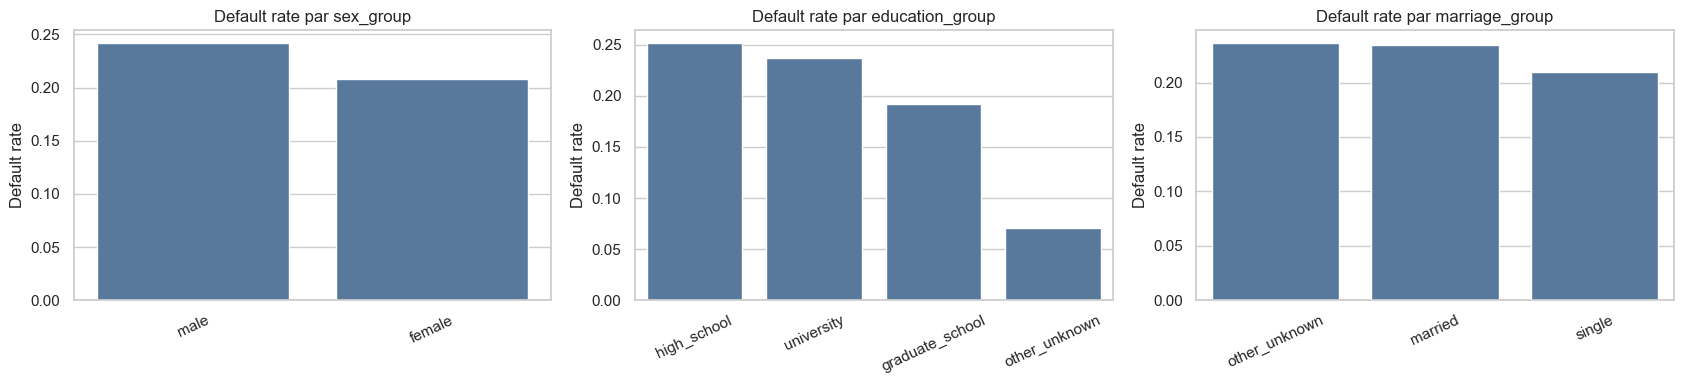

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
for ax, column in zip(axes, ["sex_group", "education_group", "marriage_group"]):
    table = default_rate_by_group(clean, column)
    sns.barplot(data=table, x=column, y="default_rate", color="#4C78A8", ax=ax)
    ax.set_title(f"Default rate par {column}")
    ax.set_xlabel("")
    ax.set_ylabel("Default rate")
    ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

**Check.** Undocumented category codes are retained through `other_unknown` groups. This avoids losing observations and keeps the transformation transparent.

## 6. Repayment Status Encoding

Raw repayment-status values are kept, and semantic categories are added. This avoids treating all status values as a single continuous numeric scale.

In [9]:
pay_mapping = pd.DataFrame(
    [{"raw_status": key, "semantic_category": value} for key, value in PAY_STATUS_MAP.items()]
).sort_values("raw_status")
display(pay_mapping)

,raw_status,semantic_category
0,-2,no_consumption
1,-1,paid_duly
2,0,revolving_credit
3,1,delay_1_month
4,2,delay_2_months
5,3,delay_3_months
6,4,delay_4_months
7,5,delay_5_months
8,6,delay_6_months
9,7,delay_7_months


,PAY_0_category,n,defaults,default_rate
8,no_consumption,2759,365,0.1323
9,paid_duly,5686,954,0.1678
10,revolving_credit,14737,1888,0.1281
0,delay_1_month,3688,1252,0.3395
1,delay_2_months,2667,1844,0.6914
2,delay_3_months,322,244,0.7578
3,delay_4_months,76,52,0.6842
4,delay_5_months,26,13,0.5000
5,delay_6_months,11,6,0.5455
6,delay_7_months,9,7,0.7778


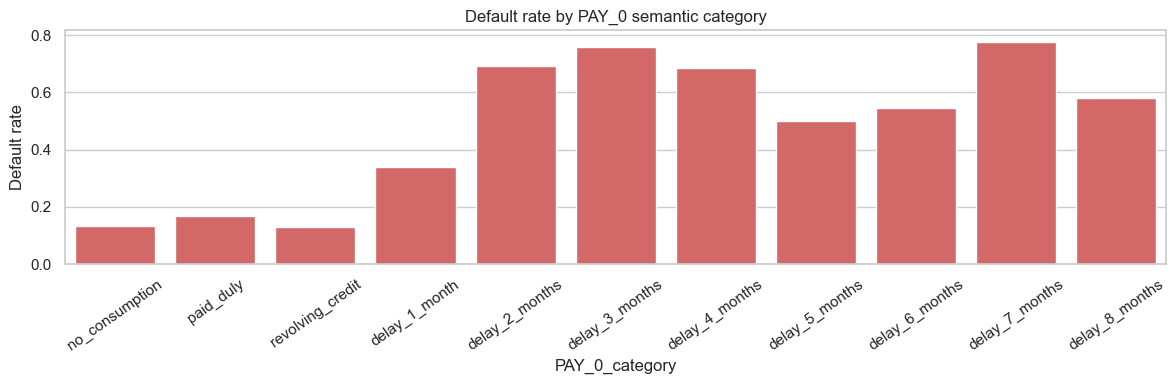

In [10]:
pay0_category_table = default_rate_by_group(clean, "PAY_0_category")
# Business order for display.
pay0_category_table["order"] = pay0_category_table["PAY_0_category"].map(
    {value: idx for idx, value in enumerate(PAY_STATUS_MAP.values())}
)
pay0_category_table = pay0_category_table.sort_values("order").drop(columns="order")
display(pay0_category_table)

fig, ax = plt.subplots(figsize=(12, 4))
sns.barplot(data=pay0_category_table, x="PAY_0_category", y="default_rate", color="#E45756", ax=ax)
ax.set_title("Default rate by PAY_0 semantic category")
ax.set_xlabel("PAY_0_category")
ax.set_ylabel("Default rate")
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

,count,mean,std,min,25%,50%,75%,max
delinquency_months,"30,000.0000",0.8342,1.5543,0.0000,0.0000,0.0000,1.0000,6.0000
severe_delinquency_months,"30,000.0000",0.7101,1.4647,0.0000,0.0000,0.0000,1.0000,6.0000
max_delay_status,"30,000.0000",0.4387,1.3452,-2.0000,0.0000,0.0000,2.0000,8.0000
recent_delay_status,"30,000.0000",-0.0167,1.1238,-2.0000,-1.0000,0.0000,0.0000,8.0000
mean_positive_delay,"30,000.0000",0.2813,0.6016,0.0000,0.0000,0.0000,0.3333,6.0000
months_no_consumption,"30,000.0000",0.8138,1.7936,0.0000,0.0000,0.0000,0.0000,6.0000
months_paid_duly,"30,000.0000",1.1547,1.9291,0.0000,0.0000,0.0000,2.0000,6.0000
months_revolving_credit,"30,000.0000",3.1973,2.5146,0.0000,0.0000,4.0000,6.0000,6.0000


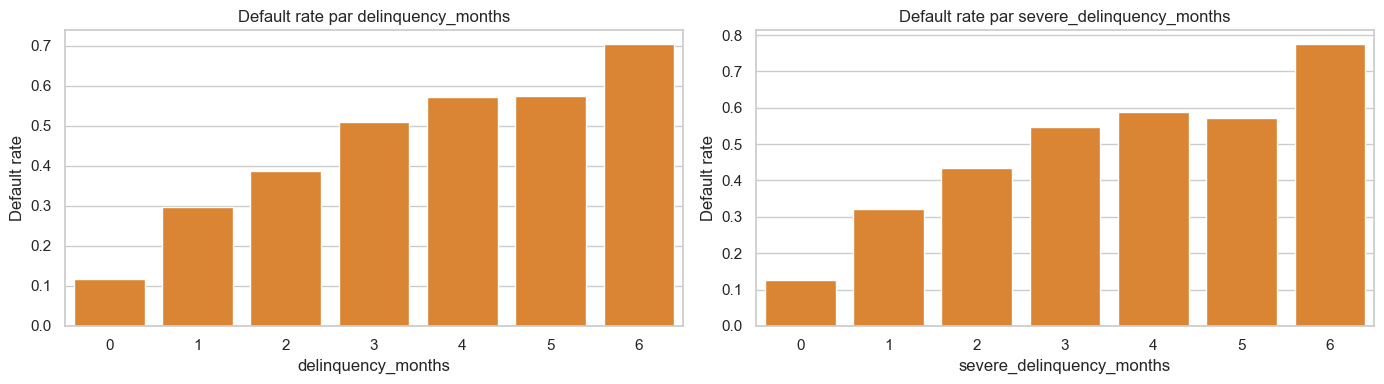

In [11]:
behavioral_columns = [
    "delinquency_months",
    "severe_delinquency_months",
    "max_delay_status",
    "recent_delay_status",
    "mean_positive_delay",
    "months_no_consumption",
    "months_paid_duly",
    "months_revolving_credit",
]

display(clean[behavioral_columns].describe().T)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, column in zip(axes, ["delinquency_months", "severe_delinquency_months"]):
    table = default_rate_by_group(clean, column).sort_values(column)
    sns.barplot(data=table, x=column, y="default_rate", color="#F58518", ax=ax)
    ax.set_title(f"Default rate par {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Default rate")
plt.tight_layout()
plt.show()

**Check.** Delinquency aggregates capture frequency and severity of late payment behavior. They are stable and easy to explain.

## 7. Amount Flags and Financial Ratios

Raw bill and payment amounts are preserved. Flags identify negative bills, non-positive bills, bills above limit, and zero-payment months. Ratios capture utilization and repayment capacity.

In [12]:
amount_flags = clean[
    [
        "negative_bill_months",
        "non_positive_bill_months",
        "bill_above_limit_months",
        "zero_payment_months",
    ]
].describe().T

display(amount_flags)

flag_rates = pd.DataFrame(
    {
        "flag": [
            "negative_bill_months > 0",
            "bill_above_limit_months > 0",
            "zero_payment_months > 0",
        ],
        "rows": [
            int((clean["negative_bill_months"] > 0).sum()),
            int((clean["bill_above_limit_months"] > 0).sum()),
            int((clean["zero_payment_months"] > 0).sum()),
        ],
    }
)
flag_rates["share"] = flag_rates["rows"] / len(clean)
display(flag_rates)

,count,mean,std,min,25%,50%,75%,max
negative_bill_months,"30,000.0000",0.1311,0.6142,0.0000,0.0000,0.0000,0.0000,6.0000
non_positive_bill_months,"30,000.0000",0.7346,1.5405,0.0000,0.0000,0.0000,1.0000,6.0000
bill_above_limit_months,"30,000.0000",0.2758,0.8697,0.0000,0.0000,0.0000,0.0000,6.0000
zero_payment_months,"30,000.0000",1.2299,1.7186,0.0000,0.0000,0.0000,2.0000,6.0000


,flag,rows,share
0,negative_bill_months > 0,1930,0.0643
1,bill_above_limit_months > 0,3931,0.1310
2,zero_payment_months > 0,14542,0.4847


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
max_utilization,"30,000.0000",0.4950,0.4330,0.0000,0.0000,0.0032,0.0706,0.4307,0.9232,1.0334,1.5775,10.6886
mean_utilization,"30,000.0000",0.3734,0.3517,0.0000,0.0000,0.0012,0.0303,0.2850,0.6884,0.9599,1.0489,5.3643
total_payment_to_bill,"30,000.0000",0.4818,5.6133,0.0000,0.0000,0.0000,0.0411,0.0864,0.5968,1.1765,2.7223,797.0000
mean_payment_to_bill,"30,000.0000",1.4503,27.8262,0.0000,0.0000,0.0000,0.0392,0.0742,0.7114,4.0021,14.6743,"3,703.4444"
mean_payment_to_limit,"30,000.0000",0.0389,0.0526,0.0000,0.0000,0.0002,0.0113,0.0261,0.0439,0.1329,0.2366,2.4277


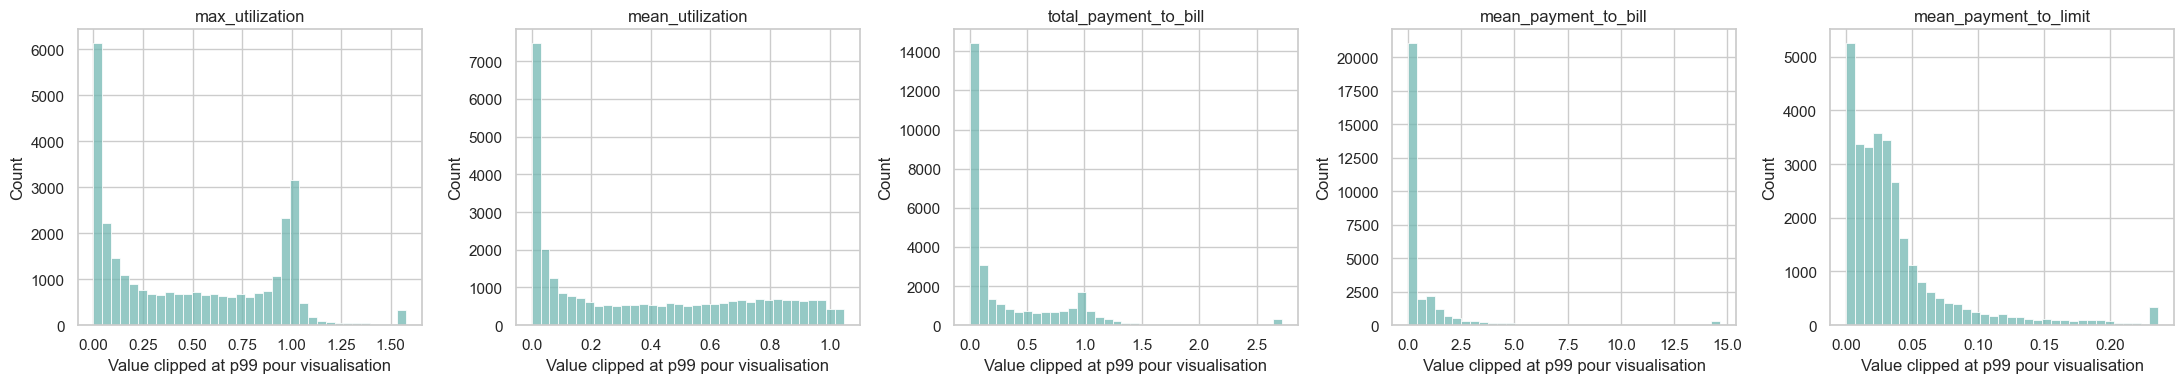

In [13]:
ratio_columns = [
    "max_utilization",
    "mean_utilization",
    "total_payment_to_bill",
    "mean_payment_to_bill",
    "mean_payment_to_limit",
]

display(clean[ratio_columns].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T)

fig, axes = plt.subplots(1, len(ratio_columns), figsize=(22, 4))
for ax, column in zip(axes, ratio_columns):
    upper = clean[column].quantile(0.99)
    sns.histplot(clean[column].clip(upper=upper), bins=35, color="#72B7B2", ax=ax)
    ax.set_title(column)
    ax.set_xlabel("Value clipped at p99 pour visualisation")
plt.tight_layout()
plt.show()

,max_utilization_decile,n,defaults,default_rate
0,"(-0.001, 0.0114]",3000,818,0.2727
1,"(0.0114, 0.0429]",3000,547,0.1823
2,"(0.0429, 0.11]",3000,451,0.1503
3,"(0.11, 0.238]",3000,426,0.1420
4,"(0.238, 0.431]",3000,529,0.1763
5,"(0.431, 0.63]",3000,664,0.2213
6,"(0.63, 0.841]",3000,730,0.2433
7,"(0.841, 0.97]",3000,784,0.2613
8,"(0.97, 1.012]",3000,760,0.2533
9,"(1.012, 1.577]",3000,927,0.3090


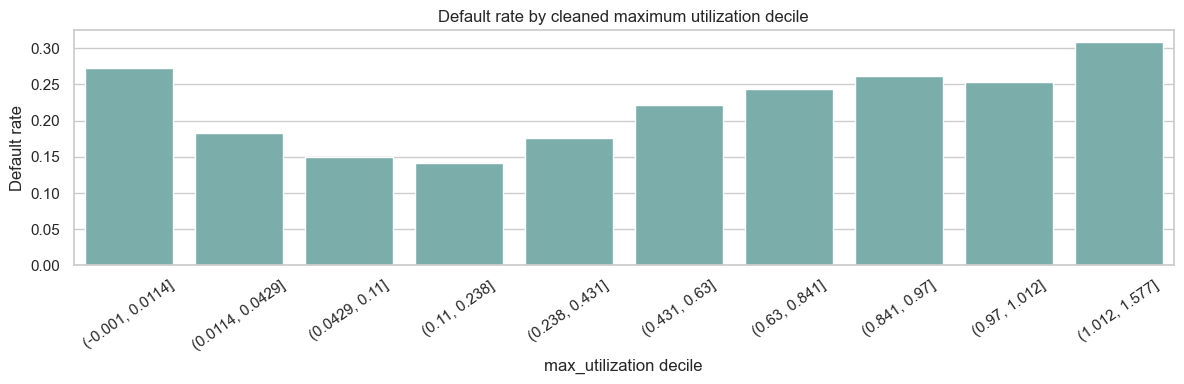

In [14]:
# Relationship between cleaned maximum utilization and default.
utilization = clean[["max_utilization", TARGET_COLUMN]].copy()
utilization["max_utilization_decile"] = pd.qcut(
    utilization["max_utilization"].clip(upper=utilization["max_utilization"].quantile(0.99)),
    q=10,
    duplicates="drop",
)
utilization_default = (
    utilization.groupby("max_utilization_decile", observed=False)[TARGET_COLUMN]
    .agg(n="size", defaults="sum", default_rate="mean")
    .reset_index()
)
utilization_default["max_utilization_decile"] = utilization_default["max_utilization_decile"].astype(str)
display(utilization_default)

fig, ax = plt.subplots(figsize=(12, 4))
sns.barplot(data=utilization_default, x="max_utilization_decile", y="default_rate", color="#72B7B2", ax=ax)
ax.set_title("Default rate by cleaned maximum utilization decile")
ax.set_xlabel("max_utilization decile")
ax.set_ylabel("Default rate")
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

**Check.** Ratio features are defined without missing values. Non-positive bills are handled through explicit flags rather than silently ignored.

## 8. Modeling Base

The modeling table excludes raw categorical codes that would be ambiguous as numeric inputs. It keeps semantic categories, continuous amounts, ratios, and behavior-based aggregates.

In [15]:
modeling_schema = pd.DataFrame(
    {
        "feature": MODELING_BASE_COLUMNS,
        "role": [
            "id" if column == "ID" else
            "target" if column == TARGET_COLUMN else
            "numeric" if column in MODEL_NUMERIC_COLUMNS else
            "categorical" if column in MODEL_CATEGORICAL_COLUMNS else
            "unknown"
            for column in MODELING_BASE_COLUMNS
        ],
        "missing": modeling[MODELING_BASE_COLUMNS].isna().sum().values,
        "unique_values": modeling[MODELING_BASE_COLUMNS].nunique().values,
    }
)

display(modeling_schema)
print(modeling_schema["role"].value_counts())

,feature,role,missing,unique_values
0,ID,id,0,30000
1,LIMIT_BAL,numeric,0,81
2,AGE,numeric,0,56
3,BILL_AMT1,numeric,0,22723
4,BILL_AMT2,numeric,0,22346
...,...,...,...,...
58,PAY_3_category,categorical,0,11
59,PAY_4_category,categorical,0,11
60,PAY_5_category,categorical,0,10
61,PAY_6_category,categorical,0,10


role
numeric        52
categorical     9
id              1
target          1
Name: count, dtype: int64


In [16]:
validation_checks = pd.DataFrame(
    {
        "check": [
            "row_count_preserved",
            "target_rate_preserved",
            "modeling_missing_cells",
            "modeling_duplicate_ids",
            "numeric_missing_cells",
            "categorical_missing_cells",
        ],
        "passed": [
            len(modeling) == len(raw),
            modeling[TARGET_COLUMN].mean() == raw[TARGET_COLUMN].mean(),
            modeling.isna().sum().sum() == 0,
            modeling["ID"].duplicated().sum() == 0,
            modeling[MODEL_NUMERIC_COLUMNS].isna().sum().sum() == 0,
            modeling[MODEL_CATEGORICAL_COLUMNS].isna().sum().sum() == 0,
        ],
    }
)
display(validation_checks)

assert validation_checks["passed"].all(), "A cleaning validation check failed."

,check,passed
0,row_count_preserved,True
1,target_rate_preserved,True
2,modeling_missing_cells,True
3,modeling_duplicate_ids,True
4,numeric_missing_cells,True
5,categorical_missing_cells,True


## 9. Operations Deferred to Modeling

Scaling, one-hot encoding, feature selection, and probability calibration should be learned inside train-only pipelines. Applying them before splitting would create leakage.

## 10. Export Cleaned Data

The analytical dataset is saved in `data/interim`; the modeling base is saved in `data/processed`. Summary tables are saved in `reports/tables`.

In [17]:
clean_path = INTERIM_DATA_DIR / "credit_default_clean.csv"
modeling_path = PROCESSED_DATA_DIR / "credit_default_modeling_base.csv"
summary_path = TABLES_DIR / "cleaning_summary.csv"
schema_path = TABLES_DIR / "modeling_base_schema.csv"
decisions_path = TABLES_DIR / "cleaning_decisions.csv"

clean.to_csv(clean_path, index=False)
modeling.to_csv(modeling_path, index=False)
summary.to_csv(summary_path, index=False)
modeling_schema.to_csv(schema_path, index=False)
cleaning_decisions.to_csv(decisions_path, index=False)

exports = pd.DataFrame(
    [
        {"artifact": "clean analytical dataset", "path": clean_path.relative_to(PROJECT_ROOT), "rows": len(clean), "columns": clean.shape[1]},
        {"artifact": "modeling base", "path": modeling_path.relative_to(PROJECT_ROOT), "rows": len(modeling), "columns": modeling.shape[1]},
        {"artifact": "cleaning summary", "path": summary_path.relative_to(PROJECT_ROOT), "rows": len(summary), "columns": summary.shape[1]},
        {"artifact": "modeling schema", "path": schema_path.relative_to(PROJECT_ROOT), "rows": len(modeling_schema), "columns": modeling_schema.shape[1]},
        {"artifact": "cleaning decisions", "path": decisions_path.relative_to(PROJECT_ROOT), "rows": len(cleaning_decisions), "columns": cleaning_decisions.shape[1]},
    ]
)
display(exports)

,artifact,path,rows,columns
0,clean analytical dataset,data\interim\credit_default_clean.csv,30000,102
1,modeling base,data\processed\credit_default_modeling_base.csv,30000,63
2,cleaning summary,reports\tables\cleaning_summary.csv,13,3
3,modeling schema,reports\tables\modeling_base_schema.csv,63,4
4,cleaning decisions,reports\tables\cleaning_decisions.csv,6,3


## 11. Summary

The cleaning step preserves row count and target distribution, standardizes category handling, adds behavioral risk features, and produces a model-ready table with no missing values.